In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import shutil
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.cm as cm
import re
import pingouin as pg
from scipy.stats import sem
import statsmodels.formula.api as smf

In [2]:
from pathlib import Path

def find_project_root(start=None):
    p = Path(os.environ.get('MAZE_PROJECT_ROOT') or start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / '_DATA').is_dir() and (cand / 'Mazes').is_dir():
            return cand
    raise RuntimeError(
        f'Could not locate the project root (a folder holding _DATA/ and Mazes/) '
        f'from {p}. Set MAZE_PROJECT_ROOT to the repository root.')

project_path = str(find_project_root())
os.chdir(project_path)

home_path  = os.path.expanduser('~')
data_path  = os.path.join(project_path, '_DATA')
maze_dir   = os.path.join(project_path, 'Mazes')
figure_path = os.path.join(project_path, 'figures')
os.makedirs(figure_path, exist_ok=True)

print(project_path)
print(data_path)

/Users/minjaejo/Desktop/2025_Maze_Behavior
/Users/minjaejo/Desktop/2025_Maze_Behavior/_DATA


### Group 1

In [ ]:
testego_cmap = ["#377eb8", "#e41a1c"]  # EgoEgo, AlloEgo
exclude_subs = []

file_types = ['EgoEgo', 'AlloEgo']
stats_list = []
collapsed_list = []
egoego_list = pd.DataFrame()
alloego_list = pd.DataFrame()

for i, file_type in enumerate(file_types):

    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]


    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)

    if not frames:
        print(f"[!] No data found for {file_type}")
        continue

    all_data = pd.concat(frames, ignore_index=True)
    filtered = all_data[all_data['PhaseView']==2].copy()
    filtered.reset_index(drop=True, inplace=True)

    cum_walls = filtered.sort_values(['subject_id', 'Trial', 'Time'])

    last_rows = (
        cum_walls.groupby(['subject_id', 'Trial'], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )

    last_rows['TrialMap'] = last_rows.groupby('subject_id').cumcount() + 1

    wallbump_all = last_rows[['subject_id', 'TrialMap', 'WallBumped']].copy()
    wallbump_all['Trial6'] = ((wallbump_all['TrialMap'] - 1) % 6) + 1

    collapsed = (
        wallbump_all.groupby(['subject_id', 'Trial6'], as_index=False)['WallBumped']
        .sum()
        .rename(columns={'Trial6': 'Trial', 'WallBumped': 'WallBumped_sum'})
    )
    collapsed['Condition'] = file_type
    collapsed_list.append(collapsed)

    collapsed.to_csv(os.path.join(project_path, f'BEH_02_Accuracy_{file_type}.csv'), index=False)

    if file_type == 'EgoEgo':
        egoego_list = pd.concat([egoego_list, collapsed], ignore_index=True)
    elif file_type == 'AlloEgo':
        alloego_list = pd.concat([alloego_list, collapsed], ignore_index=True)

    stats = (
        collapsed.groupby("Trial")["WallBumped_sum"]
        .agg(['mean', sem])
        .reset_index()
        .rename(columns={'mean': 'avg_wallbumped', 'sem': 'sem_wallbumped'})
    )
    stats['Condition'] = file_type
    stats_list.append(stats)


stats_all = pd.concat(stats_list, ignore_index=True)

### Group 2

In [ ]:
TestAllo_color_list = ['#2ca02c', '#d62728']  # AlloAllo, EgoAllo
exclude_subs = []

file_types = ['AlloAllo', 'EgoAllo']
stats_list = []
collapsed_list = []

for i, file_type in enumerate(file_types):
    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]


    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)


    all_data = pd.concat(frames, ignore_index=True)
    filtered = all_data[all_data['PhaseView']==3].copy()
    filtered.reset_index(drop=True, inplace=True)

    cum_walls = filtered.sort_values(['subject_id', 'Trial', 'Time'])

    last_rows = (
        cum_walls.groupby(['subject_id', 'Trial'], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )

    last_rows['TrialMap'] = last_rows.groupby('subject_id').cumcount() + 1

    wallbump_all = last_rows[['subject_id', 'TrialMap', 'WallBumped']].copy()

    wallbump_all['Trial6'] = ((wallbump_all['TrialMap'] - 1) % 6) + 1

    collapsed = (
        wallbump_all.groupby(['subject_id', 'Trial6'], as_index=False)['WallBumped']
        .sum()
        .rename(columns={'Trial6': 'Trial', 'WallBumped': 'WallBumped_sum'})
    )
    collapsed['Condition'] = file_type
    collapsed_list.append(collapsed)
    
    collapsed.to_csv(os.path.join(project_path, f'BEH_02_Accuracy_{file_type}.csv'), index=False)

    stats = (
        collapsed.groupby("Trial")["WallBumped_sum"]
        .agg(['mean', sem])
        .reset_index()
        .rename(columns={'mean': 'avg_wallbumped', 'sem': 'sem_wallbumped'})
    )
    stats['Condition'] = file_type
    stats_list.append(stats)


stats_all = pd.concat(stats_list, ignore_index=True)

LME — EgoEgo Test  (WallBumped)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: WallBumped_sum
No. Observations: 120     Method:             REML          
No. Groups:       20      Scale:              287.5746      
Min. group size:  6       Log-Likelihood:     -531.4015     
Max. group size:  6       Converged:          Yes           
Mean group size:  6.0                                       
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         36.737    6.484  5.665 0.000 24.027 49.446
Trial             -4.913    0.906 -5.420 0.000 -6.689 -3.136
subject_id Var   591.735   13.361                           




LME — AlloEgo Test  (WallBumped)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: WallBumped_sum
No. Observations: 120     Method:             REML          
No. Groups:       20      Scale:              662.2181      
Min. group size:  6       Log-Likelihood:     -585.1411     
Max. group size:  6       Converged:          Yes           
Mean group size:  6.0                                       
------------------------------------------------------------
                 Coef.   Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         48.280   11.907  4.055 0.000 24.942 71.618
Trial             -4.894    1.376 -3.558 0.000 -7.590 -2.198
subject_id Var  2261.844   32.652                           


LME — AlloAllo Test  (WallBumped)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: WallBumped_sum
No. Observations: 120     Method:       

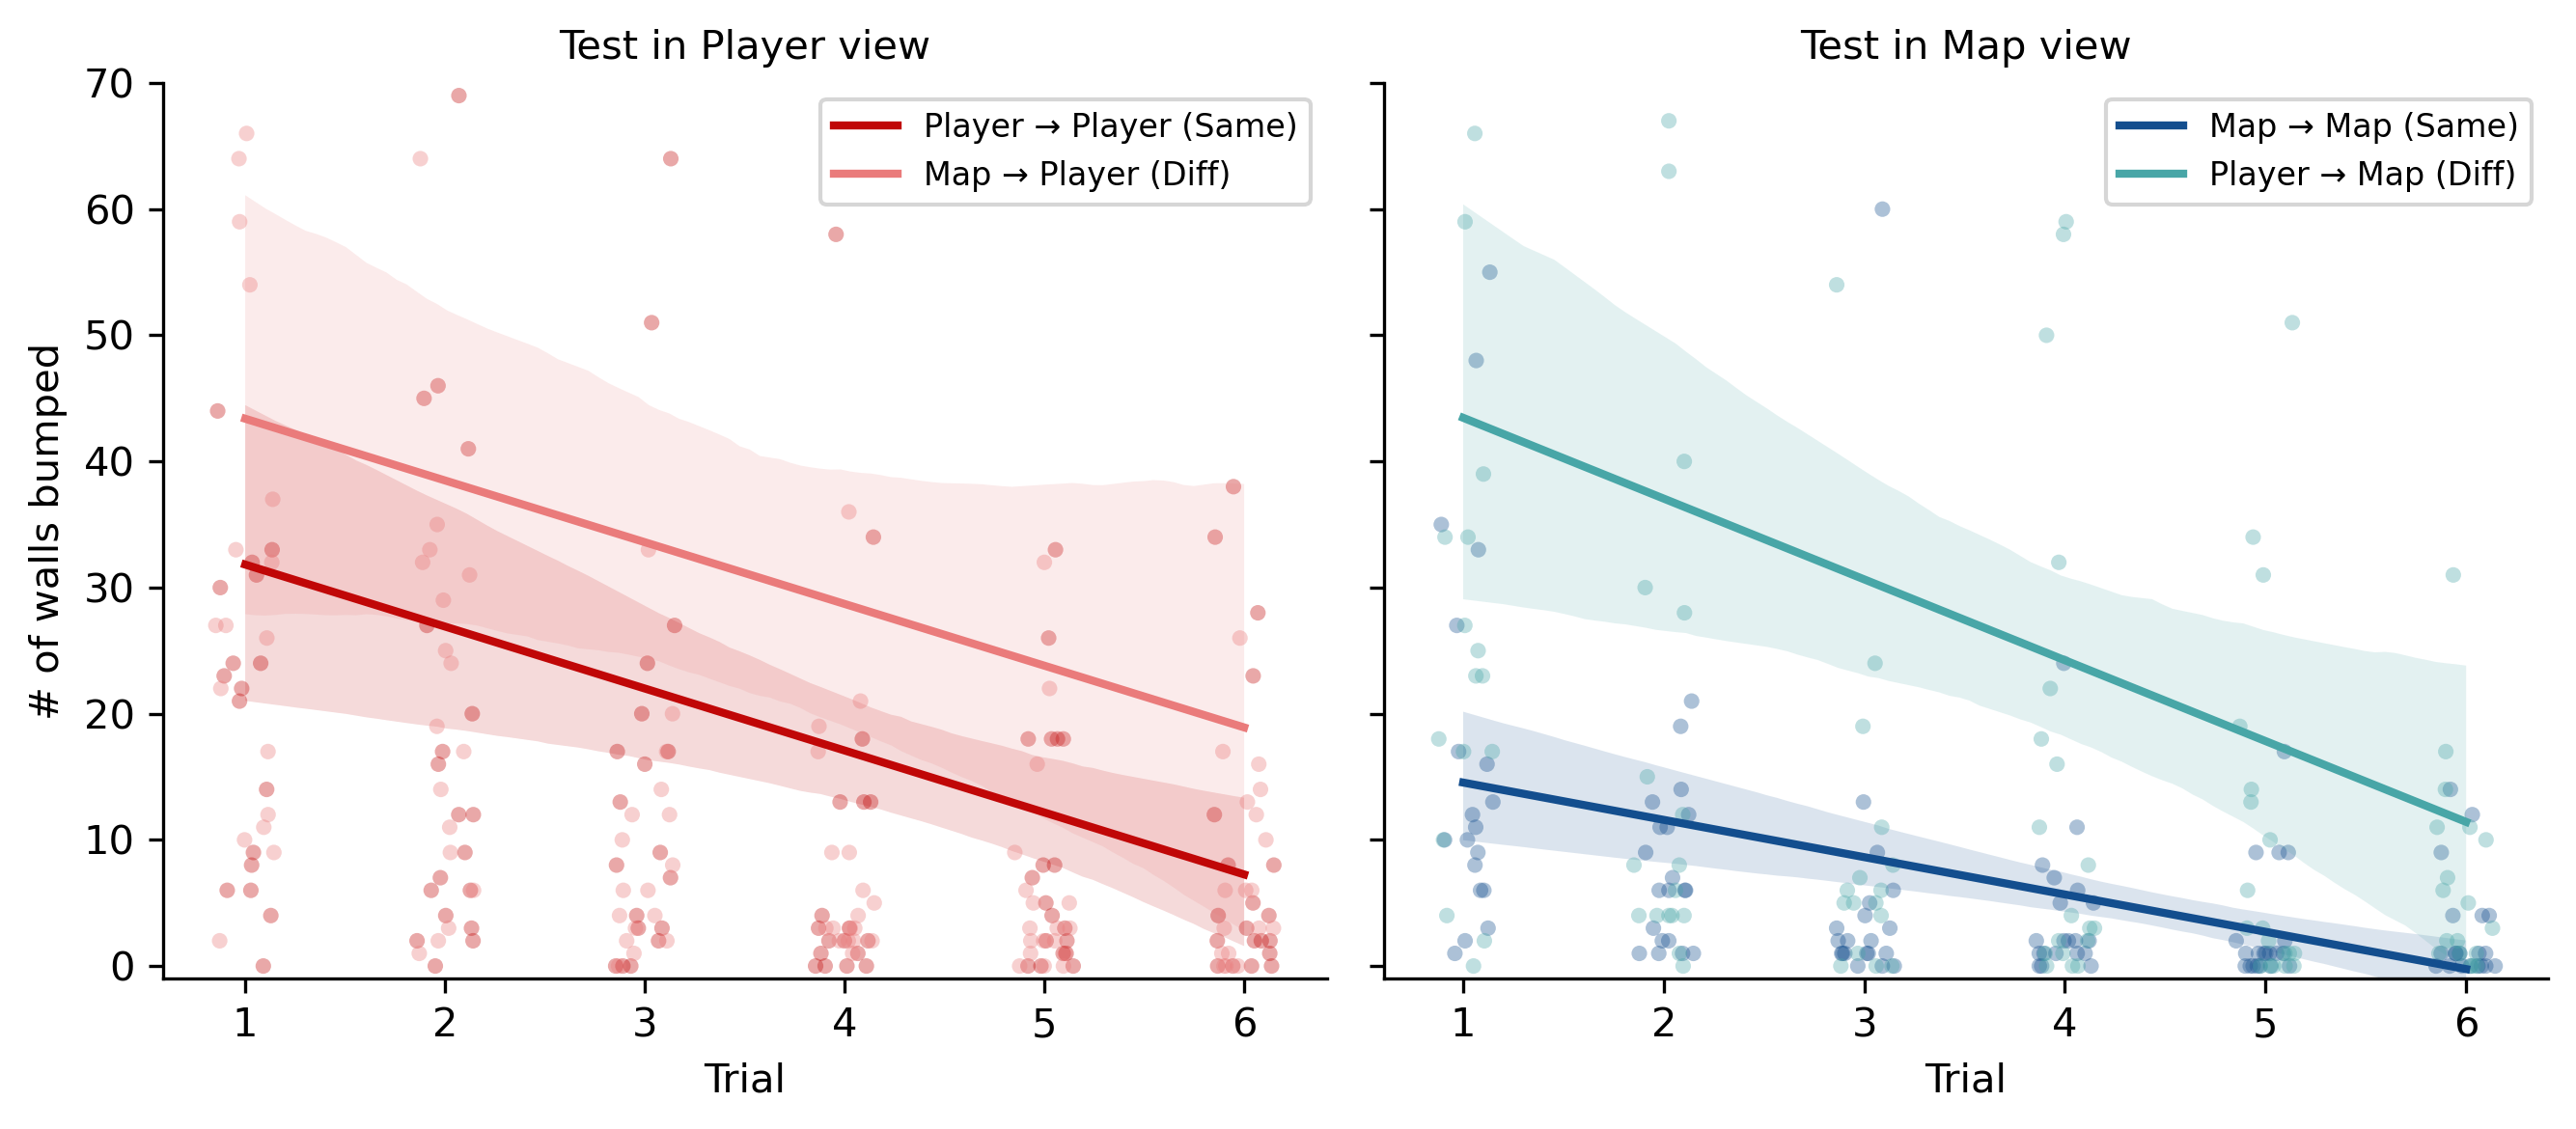

In [5]:
FIGSIZE = (9, 4)
DPI     = 300
Y_MIN, Y_MAX = -1, 70

ee = egoego_list.copy();  ee['condition'] = 'EgoEgo'
ae = alloego_list.copy();  ae['condition'] = 'AlloEgo'

g2_all = pd.concat(collapsed_list, ignore_index=True)
aa = g2_all[g2_all['Condition'] == 'AlloAllo'].copy();  aa['condition'] = 'AlloAllo'
ea = g2_all[g2_all['Condition'] == 'EgoAllo'].copy();   ea['condition'] = 'EgoAllo'

all_test = pd.concat([ee, ae, aa, ea], ignore_index=True)

# ── LME per condition ──
for cond in ['EgoEgo', 'AlloEgo', 'AlloAllo', 'EgoAllo']:
    sub = all_test[all_test['condition'] == cond]
    m = smf.mixedlm("WallBumped_sum ~ Trial", data=sub,
                     groups="subject_id", re_formula="~1").fit()
    print("=" * 60)
    print(f"LME — {cond} Test  (WallBumped)")
    print("=" * 60)
    print(m.summary())
    print()

# ── Plot: 1×2  left=Ego test (red), right=Allo test (blue) ──
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI, sharey=True)
rng = np.random.default_rng(0)

panel_specs = [
    (axes[0], 'Test in Player view', [
        ('EgoEgo',  'Player → Player (Same)', '#C00707'),
        ('AlloEgo', 'Map → Player (Diff)',    '#EA7B7B'),
    ]),
    (axes[1], 'Test in Map view', [
        ('AlloAllo', 'Map → Map (Same)',      '#134E8E'),
        ('EgoAllo',  'Player → Map (Diff)',   '#48A6A7'),
    ]),
]

for ax, title, cond_list in panel_specs:
    for cond, label, color in cond_list:
        df = all_test[all_test['condition'] == cond]
        jitter = rng.uniform(-0.15, 0.15, size=len(df))
        ax.scatter(df['Trial'] + jitter, df['WallBumped_sum'],
                   color=color, alpha=0.35, s=15, edgecolors='none')
        sns.regplot(data=df, x='Trial', y='WallBumped_sum',
                    scatter=False, ci=95, ax=ax, color=color,
                    line_kws={'lw': 2}, label=label)

    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xlabel('Trial')
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=True, fontsize=8, loc='upper right')
    sns.despine(ax=ax)

axes[0].set_ylabel('# of walls bumped')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(project_path, 'figures/BEH_02_Accuracy_AllTest.pdf'),
            bbox_inches='tight')
plt.show()